# Evil Twin Attack Detection — Decision Tree Hyperparameter Tuning

Same approach as in the previous notebooks: `GridSearchCV` run separately for each of the three cascade tasks, search performed on the train split only. The last algorithm in the list. In `../01_eda_and_prototyping.ipynb`, a single tree (`max_depth=8`) scored Attack cv=0.980, Point cv=0.724, Antenna cv=0.340 — the weakest of the tree-based models (ensembles average many trees, here there is only one). Unlike the ensembles, the tree here is also **directly interpretable** — Section 6.3 plots the tree structure itself.

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 17,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.dpi': 320,
    'savefig.dpi': 320,
})

## 2. Load Dataset & Build ML Dataset

The same resampling pipeline as in `../01_eda_and_prototyping.ipynb`/`knn.ipynb` — a synchronized vector `[s1, s2, s3, s4]` on a 5-second grid.

In [2]:
from pathlib import Path

def _find_repo_root(marker="data/rssi_raw.csv"):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not locate {marker} from {p}")

DATASET_PATH = _find_repo_root() / "data" / "rssi_raw.csv"

ANTENNA_MAP = {
    "none": 0,
    "Alfa ARS-N05": 1,
    "Alfa ARS-N19": 2,
    "Alfa APA-M25": 3,
    "AOSIYANT Yagi 16dBi": 4,
    "Logperiodic": 5,
    "Alfa APA-M04": 6,
}
ANTENNA_NAMES = {v: k for k, v in ANTENNA_MAP.items()}

raw = pd.read_csv(DATASET_PATH, parse_dates=["time"])

# Resample each sensor to a 5s grid, fill gaps with nearest value
sensors = {}
for i in range(1, 5):
    s = raw[raw["deviceID"] == f"sensor_{i}"][["time", "value"]].copy()
    s = s.set_index("time").sort_index()
    s = s.resample("5s").median()
    s = s.interpolate(method="nearest")
    s = s.rename(columns={"value": f"s{i}"})
    sensors[i] = s

# Inner join — keep only timestamps where all 4 sensors have data
df_pivot = sensors[1]
for i in range(2, 5):
    df_pivot = df_pivot.join(sensors[i], how="inner")

df_pivot = df_pivot.dropna().reset_index()

# Attach point/attack/antenna labels via nearest-time match against the raw labels
labels = raw[["time", "point", "attack", "antenna"]].drop_duplicates("time").sort_values("time")
dataset = pd.merge_asof(df_pivot.sort_values("time"), labels, on="time", direction="nearest")
dataset = dataset[["time", "s1", "s2", "s3", "s4", "point", "attack", "antenna"]]

print(f"Dataset shape: {dataset.shape}")
dataset.head()

Dataset shape: (2131, 8)


,time,s1,s2,s3,s4,point,attack,antenna
0,2026-05-23 14:30:05+03:00,-56.0,-54.0,-62.0,-60.0,0,0,0
1,2026-05-23 14:30:10+03:00,-55.0,-54.0,-64.0,-60.0,0,0,0
2,2026-05-23 14:30:15+03:00,-56.0,-53.0,-55.0,-60.0,0,0,0
3,2026-05-23 14:30:20+03:00,-56.0,-54.0,-55.0,-59.0,0,0,0
4,2026-05-23 14:30:25+03:00,-55.0,-54.0,-57.0,-61.0,0,0,0


## 3. Train/Test Split (Cascade)

In [3]:
features = ["s1", "s2", "s3", "s4"]
X = dataset[features]

# ── Split: full dataset (for attack detection) ──
y_attack = dataset["attack"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_attack, test_size=0.25, random_state=42, stratify=y_attack
)

# ── Split: attack-only (for point & antenna) ──
attack_mask = dataset["attack"] == 1
X_attack    = dataset.loc[attack_mask, features]
y_point     = dataset.loc[attack_mask, "point"]
y_antenna   = dataset.loc[attack_mask, "antenna"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_attack, y_point, test_size=0.25, random_state=42, stratify=y_point
)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_attack, y_antenna, test_size=0.25, random_state=42, stratify=y_antenna
)

print(f"Full dataset:   train={len(X_train)}, test={len(X_test)}")
print(f"Attack-only:    train={len(X_train_p)}, test={len(X_test_p)}")

Full dataset:   train=1598, test=533
Attack-only:    train=428, test=143


## 4. Baseline Decision Tree (max_depth=8, default)

Starting point — the same tree that already appeared in `../01_eda_and_prototyping.ipynb`.

In [4]:
tasks = {
    "Attack Detection":   (X_train,   y_train,   X_test,   y_test,   X,        y_attack),
    "Point Prediction":   (X_train_p, y_train_p, X_test_p, y_test_p, X_attack, y_point),
    "Antenna Prediction": (X_train_a, y_train_a, X_test_a, y_test_a, X_attack, y_antenna),
}

baseline_results = {}
for name, (Xtr, ytr, Xte, yte, Xfull, yfull) in tasks.items():
    m = DecisionTreeClassifier(max_depth=8, random_state=42)
    m.fit(Xtr, ytr)
    acc = accuracy_score(yte, m.predict(Xte))
    cv  = cross_val_score(DecisionTreeClassifier(max_depth=8, random_state=42), Xfull, yfull, cv=5).mean()
    baseline_results[name] = (acc, cv)
    print(f"{name:<20} acc={acc:.3f}  cv={cv:.3f}  (max_depth=8, default)")

Attack Detection     acc=0.983  cv=0.980  (max_depth=8, default)
Point Prediction     acc=0.811  cv=0.724  (max_depth=8, default)
Antenna Prediction   acc=0.650  cv=0.340  (max_depth=8, default)


## 5. GridSearchCV Hyperparameter Search

We sweep `max_depth`, `min_samples_split`, `min_samples_leaf`, and `criterion` separately for each of the three cascade tasks, with 5-fold CV. Search performed on the train split only.

In [5]:
param_grid = {
    "max_depth": [3, 5, 8, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
}

def run_grid_search(X_tr, y_tr, X_full, y_full, label):
    search = GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        param_grid, cv=5, scoring="accuracy", n_jobs=-1,
    )
    search.fit(X_tr, y_tr)  # train split only — best_estimator_ never sees the held-out test split

    # Full-dataset CV with the winning hyperparams, for apples-to-apples comparison with baseline_results
    full_cv = cross_val_score(
        DecisionTreeClassifier(random_state=42, **search.best_params_), X_full, y_full, cv=5
    ).mean()

    print(f"{label:<20} train-CV={search.best_score_:.3f}  full-CV={full_cv:.3f}  params={search.best_params_}")
    return search, full_cv

search_attack,  full_cv_attack  = run_grid_search(X_train,   y_train,   X,        y_attack,  "Attack Detection")
search_point,   full_cv_point   = run_grid_search(X_train_p, y_train_p, X_attack, y_point,   "Point Prediction")
search_antenna, full_cv_antenna = run_grid_search(X_train_a, y_train_a, X_attack, y_antenna, "Antenna Prediction")

Attack Detection     train-CV=0.987  full-CV=0.986  params={'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 20}
Point Prediction     train-CV=0.883  full-CV=0.715  params={'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Antenna Prediction   train-CV=0.720  full-CV=0.394  params={'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [6]:
print("=" * 95)
print("Tuned Decision Tree vs Baseline (max_depth=8) — 5-fold CV Accuracy (full dataset)")
print("=" * 95)
print(f"{'Model':<20} {'Baseline CV':>12} {'Tuned CV':>10} {'Delta':>8}   Best params")
print("-" * 95)
for label, full_cv, search in [
    ("Attack Detection",   full_cv_attack,  search_attack),
    ("Point Prediction",   full_cv_point,   search_point),
    ("Antenna Prediction", full_cv_antenna, search_antenna),
]:
    base_cv = baseline_results[label][1]
    delta = full_cv - base_cv
    print(f"{label:<20} {base_cv:>12.3f} {full_cv:>10.3f} {delta:>+8.3f}   {search.best_params_}")

Tuned Decision Tree vs Baseline (max_depth=8) — 5-fold CV Accuracy (full dataset)
Model                 Baseline CV   Tuned CV    Delta   Best params
-----------------------------------------------------------------------------------------------
Attack Detection            0.980      0.986   +0.006   {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 20}
Point Prediction            0.724      0.715   -0.009   {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Antenna Prediction          0.340      0.394   +0.054   {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}


### 5.1 Accuracy vs max_depth

A tree has no `n_estimators` — instead we fix the best `min_samples_split`/`min_samples_leaf`/`criterion` from the grid search and scan `max_depth` on a denser grid (1–20), to see the classic U-shaped bias/variance trade-off curve of a single tree.

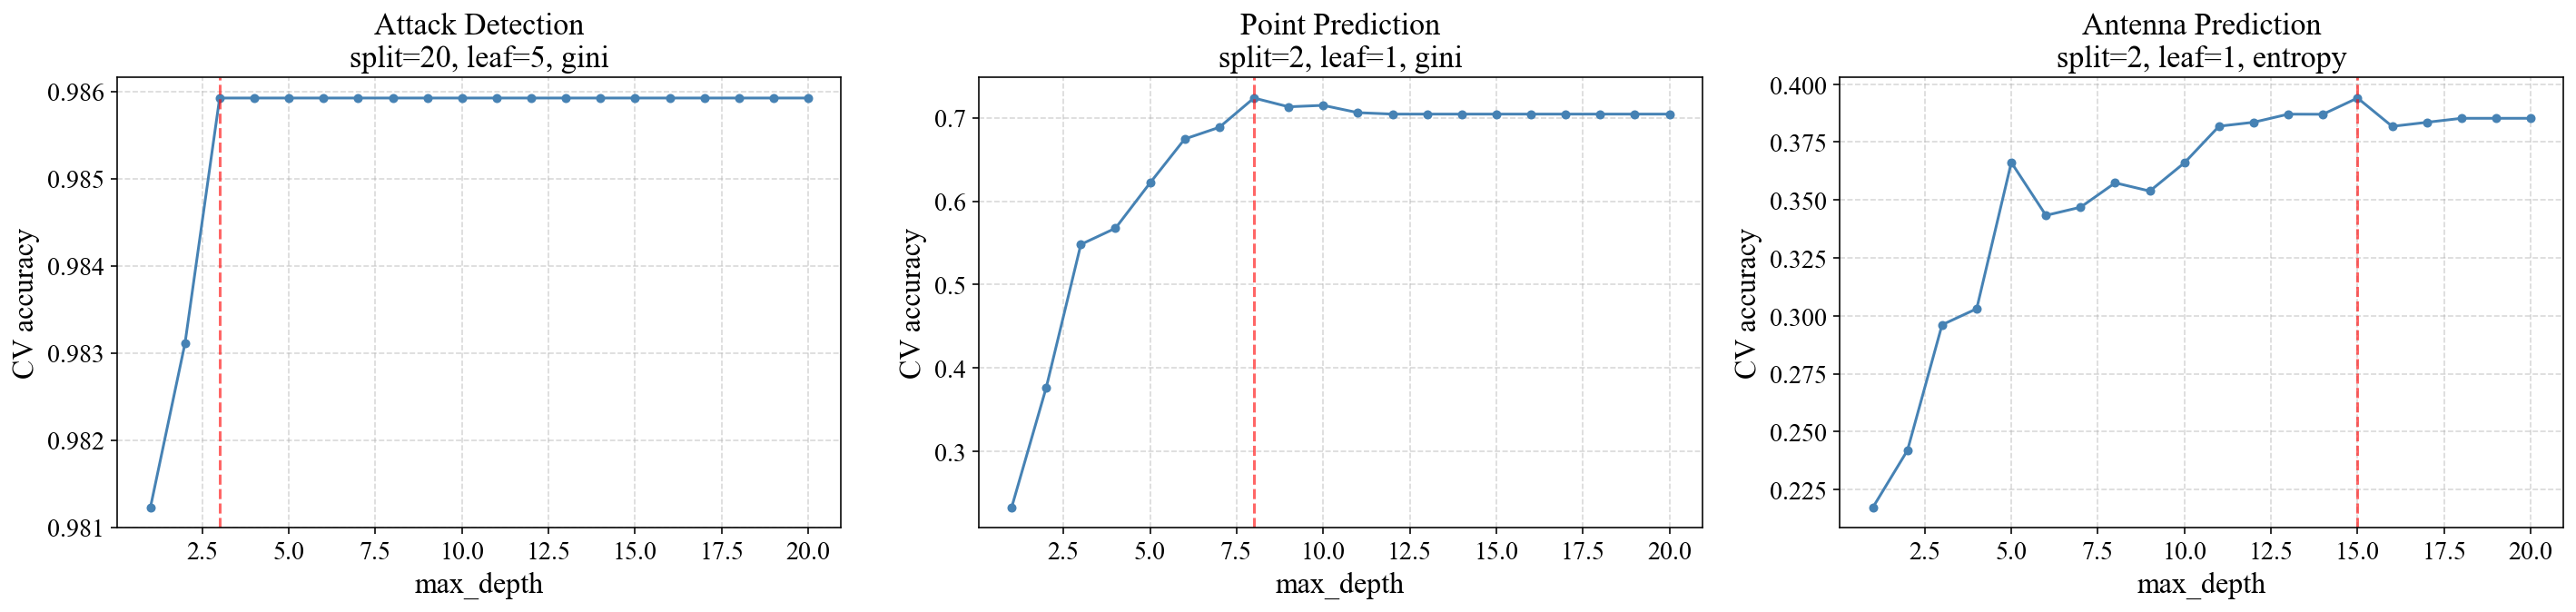

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

curve_tasks = [
    ("Attack Detection",   X,        y_attack,  search_attack.best_params_),
    ("Point Prediction",   X_attack, y_point,   search_point.best_params_),
    ("Antenna Prediction", X_attack, y_antenna, search_antenna.best_params_),
]

depth_range = list(range(1, 21))

for ax, (label, Xd, yd, best_params) in zip(axes, curve_tasks):
    fixed = {k: v for k, v in best_params.items() if k != "max_depth"}
    scores = [
        cross_val_score(
            DecisionTreeClassifier(random_state=42, max_depth=d, **fixed), Xd, yd, cv=5
        ).mean()
        for d in depth_range
    ]
    best_d = depth_range[int(np.argmax(scores))]

    ax.plot(depth_range, scores, marker="o", markersize=4, color="#4682B4")
    ax.axvline(best_d, color="red", linestyle="--", alpha=0.6)
    ax.set_title(f"{label}\nsplit={fixed['min_samples_split']}, leaf={fixed['min_samples_leaf']}, {fixed['criterion']}")
    ax.set_xlabel("max_depth")
    ax.set_ylabel("CV accuracy")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Final Tuned Decision Tree Models

We train `best_estimator_` from the grid search on each task's train split and evaluate on the held-out test split.

In [8]:
dt_attack  = search_attack.best_estimator_
dt_point   = search_point.best_estimator_
dt_antenna = search_antenna.best_estimator_

y_pred_attack_dt  = dt_attack.predict(X_test)
y_pred_point_dt   = dt_point.predict(X_test_p)
y_pred_antenna_dt = dt_antenna.predict(X_test_a)

print(f"Test accuracy — Attack Detection:   {accuracy_score(y_test, y_pred_attack_dt):.3f}")
print(f"Test accuracy — Point Prediction:   {accuracy_score(y_test_p, y_pred_point_dt):.3f}")
print(f"Test accuracy — Antenna Prediction: {accuracy_score(y_test_a, y_pred_antenna_dt):.3f}")

print(f"\n{classification_report(y_test, y_pred_attack_dt, target_names=['No Attack', 'Attack'])}")

Test accuracy — Attack Detection:   0.983
Test accuracy — Point Prediction:   0.825
Test accuracy — Antenna Prediction: 0.734

              precision    recall  f1-score   support

   No Attack       0.99      0.98      0.99       390
      Attack       0.96      0.98      0.97       143

    accuracy                           0.98       533
   macro avg       0.98      0.98      0.98       533
weighted avg       0.98      0.98      0.98       533



### 6.1 Confusion Matrices (Tuned Decision Tree)

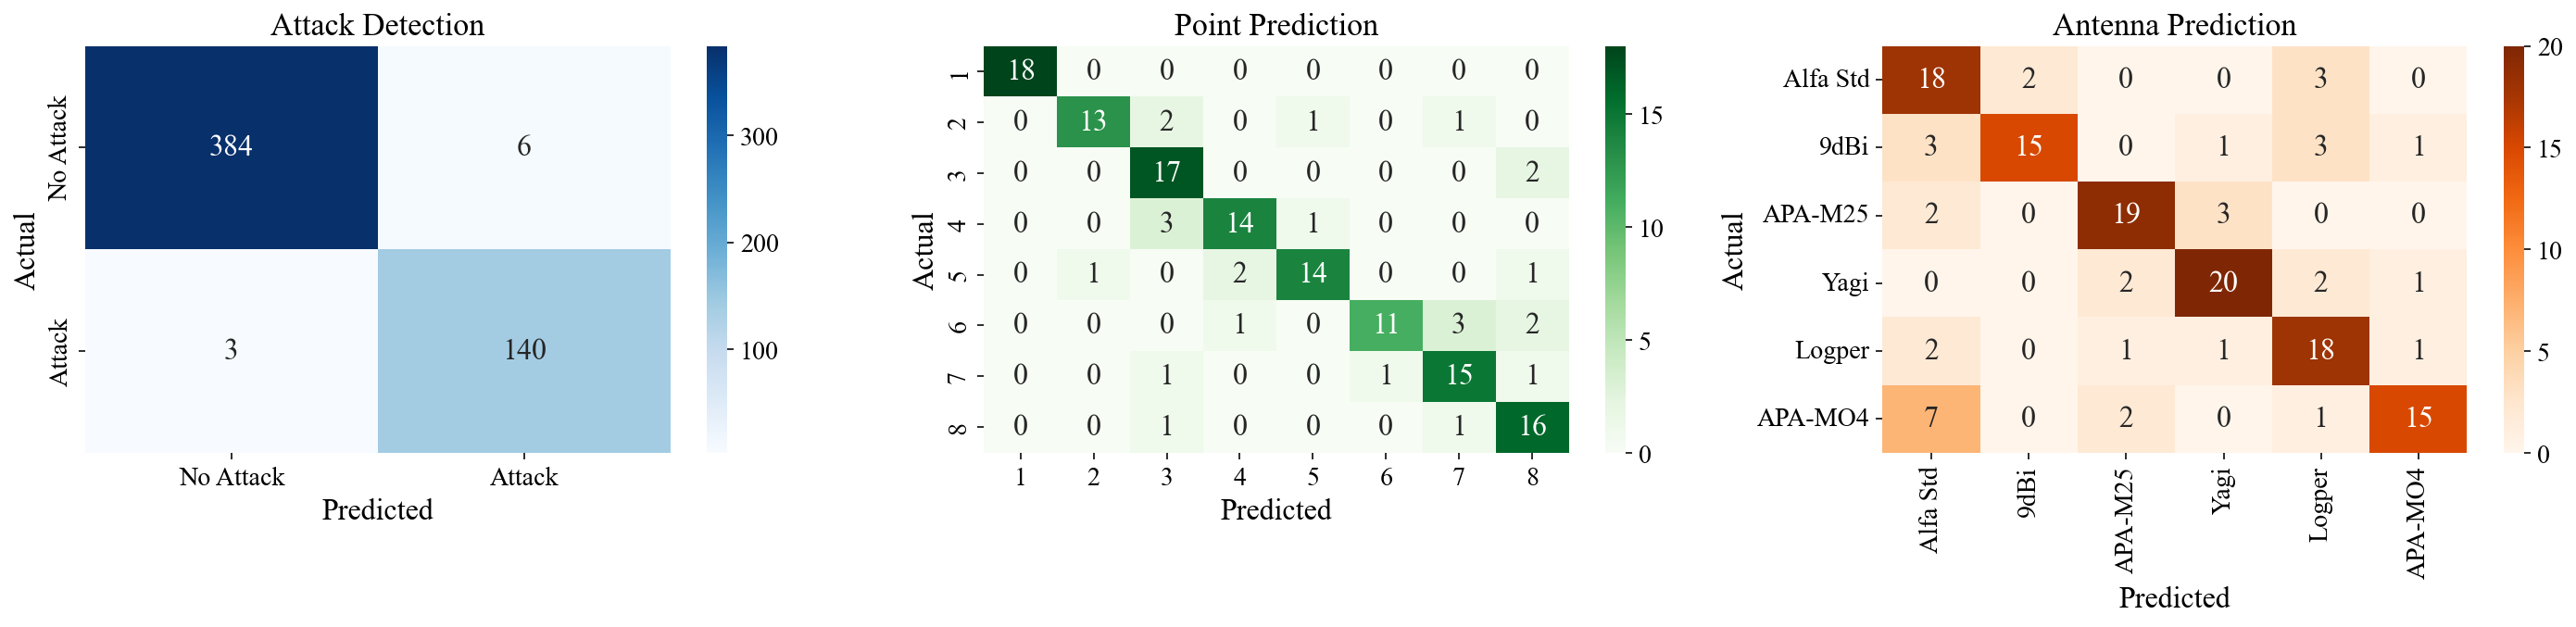

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm1 = confusion_matrix(y_test, y_pred_attack_dt)
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Attack", "Attack"], yticklabels=["No Attack", "Attack"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual"); axes[0].set_title("Attack Detection")

labels_p = sorted(y_point.unique())
cm2 = confusion_matrix(y_test_p, y_pred_point_dt, labels=labels_p)
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=labels_p, yticklabels=labels_p)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual"); axes[1].set_title("Point Prediction")

labels_a = sorted(y_antenna.unique())
antenna_short = ["ARS-N05", "ARS-N19", "APA-M25", "Yagi", "Logper", "APA-M04"]
cm3 = confusion_matrix(y_test_a, y_pred_antenna_dt, labels=labels_a)
sns.heatmap(cm3, annot=True, fmt="d", cmap="Oranges", ax=axes[2],
            xticklabels=antenna_short, yticklabels=antenna_short)
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual"); axes[2].set_title("Antenna Prediction")

plt.tight_layout()
plt.show()

### 6.2 Feature Importance (Tuned Decision Tree)

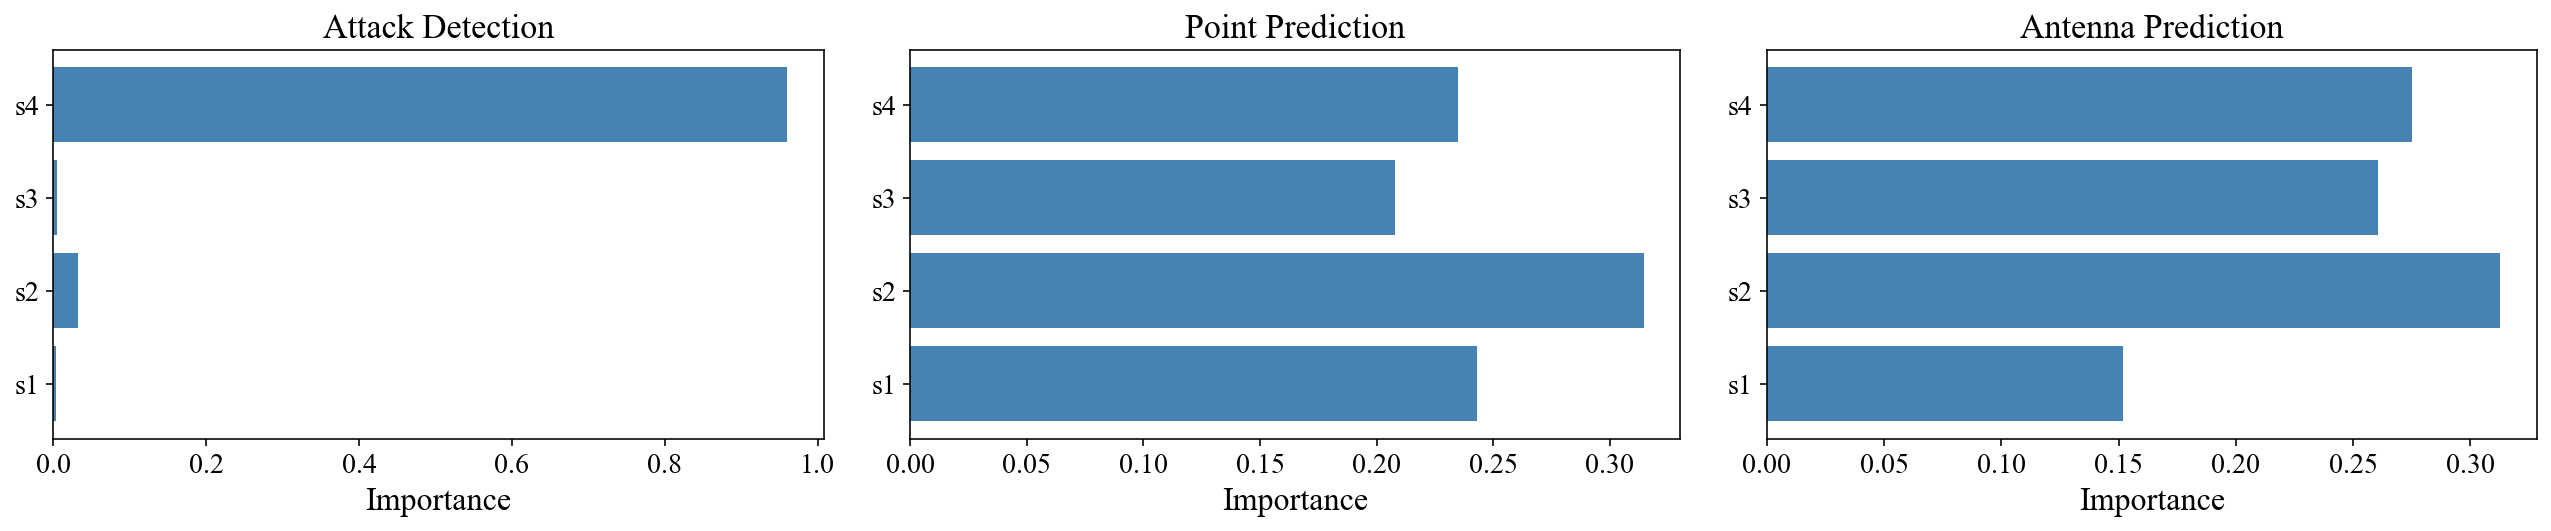

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, model, title in zip(
    axes, [dt_attack, dt_point, dt_antenna],
    ["Attack Detection", "Point Prediction", "Antenna Prediction"],
):
    importances = model.feature_importances_
    ax.barh(features, importances, color="#4682B4")
    ax.set_xlabel("Importance")
    ax.set_title(title)

plt.tight_layout()
plt.show()

### 6.3 Tree Visualization (Attack Detection)

Unlike ensembles (RF/ET/boosting), a single tree can be shown directly — here we plot the first 3 levels of `dt_attack` (the full tree would be too long to read).

Full tree depth: 3, leaves: 6


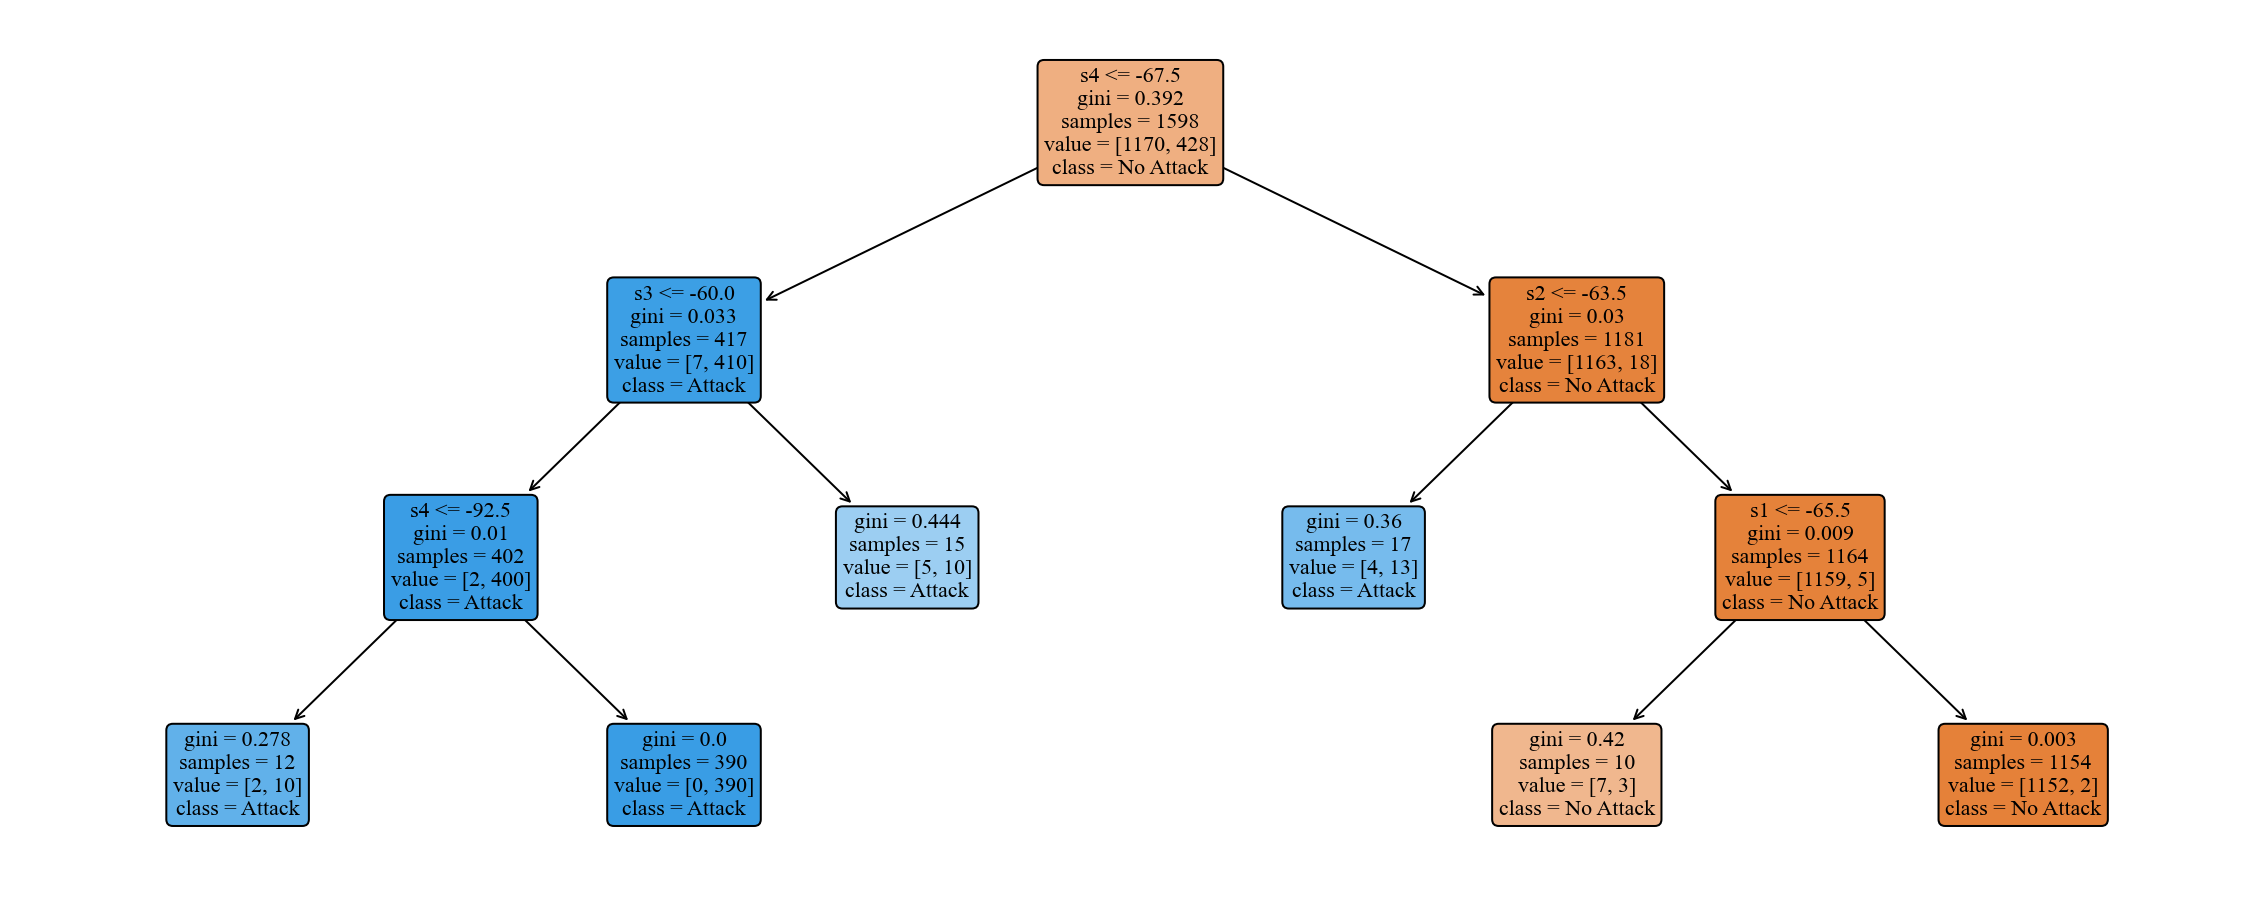

In [11]:
print(f"Full tree depth: {dt_attack.get_depth()}, leaves: {dt_attack.get_n_leaves()}")

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_attack, max_depth=3, feature_names=features, class_names=["No Attack", "Attack"],
    filled=True, rounded=True, fontsize=11, ax=ax,
)
plt.show()

## 7. Inference

In [12]:
def predict(s1, s2, s3, s4):
    """
    Predict attack status from 4 sensor RSSI values, using the tuned Decision Tree cascade.

    Returns dict with:
      - attack: bool
      - point:  int (1-8) or None
      - antenna: str or None
      - confidence: dict with probabilities
    """
    X_input = pd.DataFrame([[s1, s2, s3, s4]], columns=features)

    # Step 1: Attack detection
    attack_prob = dt_attack.predict_proba(X_input)[0]
    is_attack = dt_attack.predict(X_input)[0] == 1

    result = {
        "attack": is_attack,
        "attack_confidence": f"{attack_prob[1] * 100:.1f}%",
        "point": None,
        "point_confidence": None,
        "antenna": None,
        "antenna_confidence": None,
    }

    if not is_attack:
        print(f"✅ No attack detected (confidence: {attack_prob[0] * 100:.1f}%)")
        return result

    # Step 2: Point prediction
    point = dt_point.predict(X_input)[0]
    point_prob = dt_point.predict_proba(X_input)[0]
    point_conf = point_prob.max() * 100

    # Step 3: Antenna prediction
    antenna_code = dt_antenna.predict(X_input)[0]
    antenna_name = ANTENNA_NAMES[antenna_code]
    antenna_prob = dt_antenna.predict_proba(X_input)[0]
    antenna_conf = antenna_prob.max() * 100

    result.update({
        "point": int(point),
        "point_confidence": f"{point_conf:.1f}%",
        "antenna": antenna_name,
        "antenna_confidence": f"{antenna_conf:.1f}%",
    })

    print(f"🚨 ATTACK DETECTED (confidence: {attack_prob[1] * 100:.1f}%)")
    print(f"   📍 Point: {point} (confidence: {point_conf:.1f}%)")
    print(f"   📡 Antenna: {antenna_name} (confidence: {antenna_conf:.1f}%)")

    return result


# --- Test ---
print("=== Test: baseline signal ===")
predict(-55, -54, -57, -59)

print("\n=== Test: attack signal ===")
predict(-70, -69, -74, -77)

=== Test: baseline signal ===
✅ No attack detected (confidence: 99.8%)

=== Test: attack signal ===
🚨 ATTACK DETECTED (confidence: 100.0%)
   📍 Point: 2 (confidence: 100.0%)
   📡 Antenna: Alfa ARS-N05 (confidence: 100.0%)


{'attack': True,
 'attack_confidence': '100.0%',
 'point': 2,
 'point_confidence': '100.0%',
 'antenna': 'Alfa ARS-N05',
 'antenna_confidence': '100.0%'}